# DLAG-SSM with Matérn-5/2 kernel

> **Engine class: SSM-GP (exact)** - Matérn-5/2 has a closed-form finite-state SDE realization (state dim 3). `KalmanEMEngine` consumes it directly with **no AR(P) approximation** - unlike MOSE/RBF which is approximated.


Drop-in alternative to `demo_dlag_ssm.ipynb` (which uses MOSE/RBF). `Matern52Kernel` has an exact finite-state SDE realization - the Kalman engine uses it directly with no AR(P) approximation.

Scenario: identical to `demo_dlag_ssm.ipynb` so the two figures compare on the kernel axis alone.

See `examples/demo_matern.py` for the CLI equivalent.

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch
from mbrila import DLAG, KalmanEMEngine, LatentSpec, Matern52Kernel
from mbrila.synthetic.multiregion import MultiRegionScenario

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## Scenario

In [2]:
n_trials, T, n_regions = 50, 200, 5
y_dim_per_region, n_across, n_within = 100, 2, 1
sigma_across, sigma_within = 0.05, 0.05
delay_amplitude = 3.0
per_latent_sigma_ratio, per_latent_amp_ratio = 10.0, 3.0

scenario = MultiRegionScenario(  # noqa: F821
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=n_across,
    n_within=n_within,
    lag_across=2,
    lag_within=2,
    sigma_across=sigma_across,
    sigma_within=sigma_within,
    delay_shape="constant",
    delay_amplitude=delay_amplitude,
    per_latent_amplitudes=tuple(
        delay_amplitude * (1.0 / per_latent_amp_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_shapes=tuple(["constant"] * n_across),
    region_heterogeneity=1.0,
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}"
)

data.y shape = (50, 200, 500)
truth['delay'] shape = (200, 4, 2)
truth['observable'] shape = (50, 200, 15)


## Build & fit model

Same `KalmanEMEngine` recipe as the MOSE notebook, with `Matern52Kernel` as the per-block kernel.

In [3]:
spec = LatentSpec(
    n_across=n_across,
    n_within=(n_within,) * n_regions,
)
engine = KalmanEMEngine(
    lr=1e-2,
    lr_min=1e-3,
    weight_decay=1e-2,
    log_every=25,
)
# Init lengthscale ≈ 2 bins - neither matches truth slow (~10) nor fast (~3) effective ℓ.
init_ell = 2.0
model = DLAG(
    latent_spec=spec,
    y_dims=scenario.y_dims,
    T=scenario.T,
    kernel_factory_across=lambda: Matern52Kernel(lengthscale=init_ell),
    kernel_factory_within=lambda: Matern52Kernel(lengthscale=init_ell),
    engine="kalman",
    engine_override=engine,
    device=device,
    dtype=torch.float64,
).to(device)

model.initialize_from_data(data, mode="pcca")

result = model.fit(data, max_iter=300, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[kalman_em] iter 25/300  E_q[log p(x,y)] = 1513238.352


[kalman_em] iter 50/300  E_q[log p(x,y)] = 1585423.664


[kalman_em] iter 75/300  E_q[log p(x,y)] = 1655700.705


[kalman_em] iter 100/300  E_q[log p(x,y)] = 1703732.868


[kalman_em] iter 125/300  E_q[log p(x,y)] = 1728558.628


...

[kalman_em] iter 225/300  E_q[log p(x,y)] = 1763900.131


[kalman_em] iter 250/300  E_q[log p(x,y)] = 1766473.614


[kalman_em] iter 275/300  E_q[log p(x,y)] = 1768194.223


[kalman_em] iter 300/300  E_q[log p(x,y)] = 1769492.911


fit done: 300 iters, wall = 330.9s


## Extract fitted quantities

In [4]:
fitted_delay = demo.extract_delay(model, scenario.T)
fitted_obs = demo.extract_observable(model, data)
fitted_y = demo.extract_y_recon(model, data)

fitted_obs_aligned, fitted_delay_aligned, perm = nb.align_and_repermute(
    truth["observable"],
    fitted_obs,
    fitted_delay,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
)
delay_rmse = demo.pair_rmse(fitted_delay_aligned, truth["delay"], n_regions)
print(f"across-latent permutation (truth -> fit slot) = {perm}")
print(f"delay_rmse after alignment = {delay_rmse:.4f} bins")

across-latent permutation (truth -> fit slot) = (0, 1)
delay_rmse after alignment = 0.0221 bins


## Figure 1 - Convergence

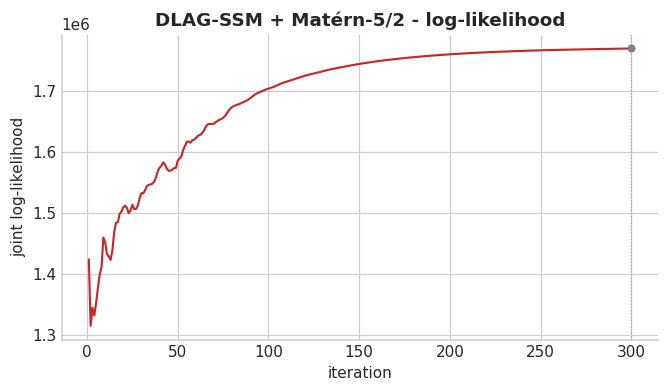

In [5]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="DLAG-SSM + Matérn-5/2 - log-likelihood")

## Figure 2 - Delay comparison (truth vs fit, per pair)

One panel per `(latent, region pair)`. Truth dashed-purple, fit solid-darkred.

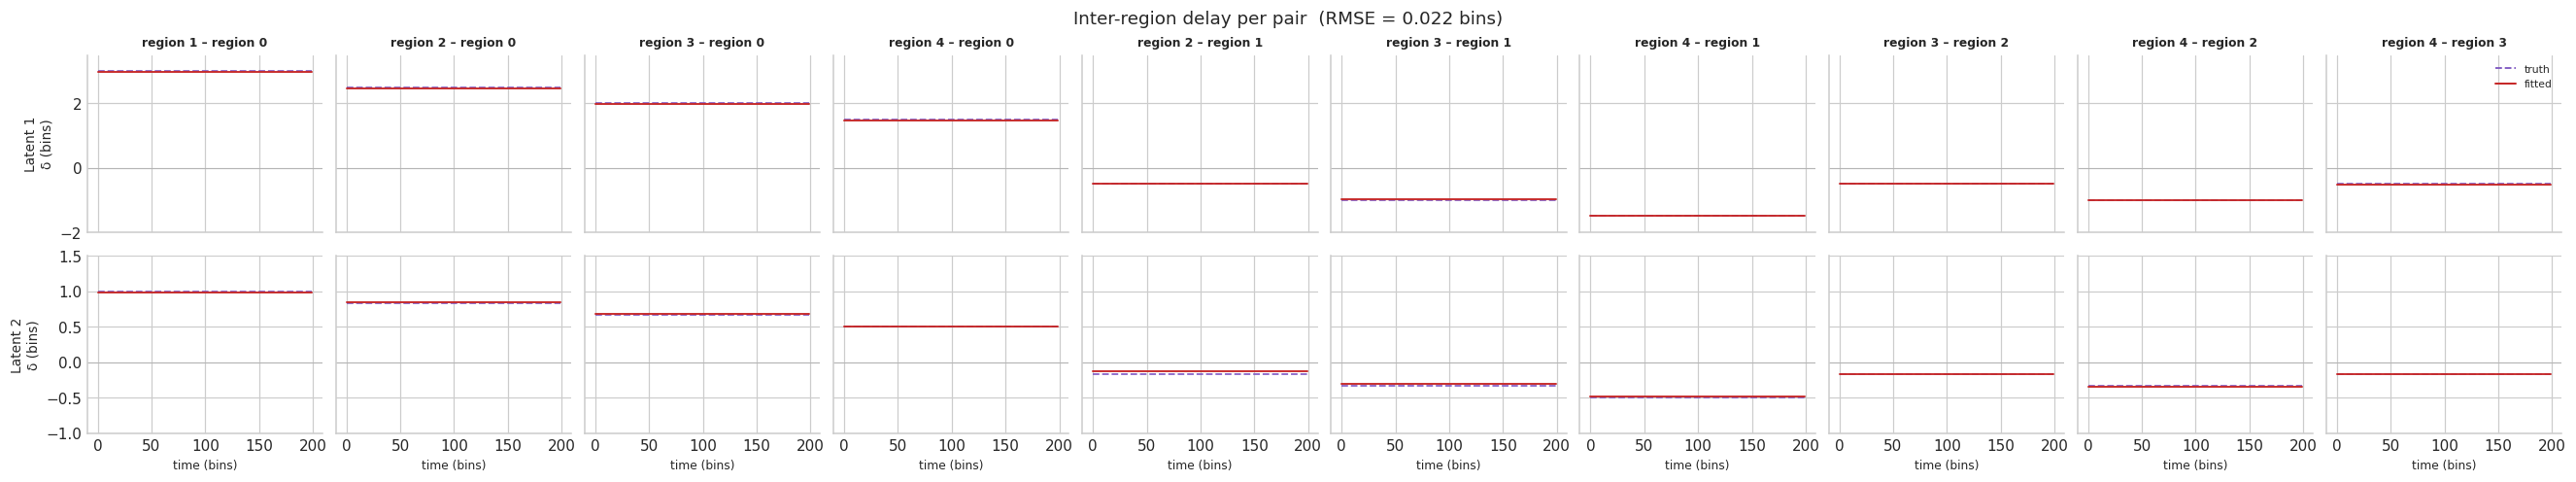

In [6]:
_ = nb.plot_delay_comparison(
    truth["delay"],
    fitted_delay_aligned,
    n_regions=n_regions,
    n_across=n_across,
    rmse=delay_rmse,
)

## Figure 3 - Per-latent traces (trial 0)

One panel per `(latent, region)`. Truth dashed, fit solid (sign-aligned per panel).

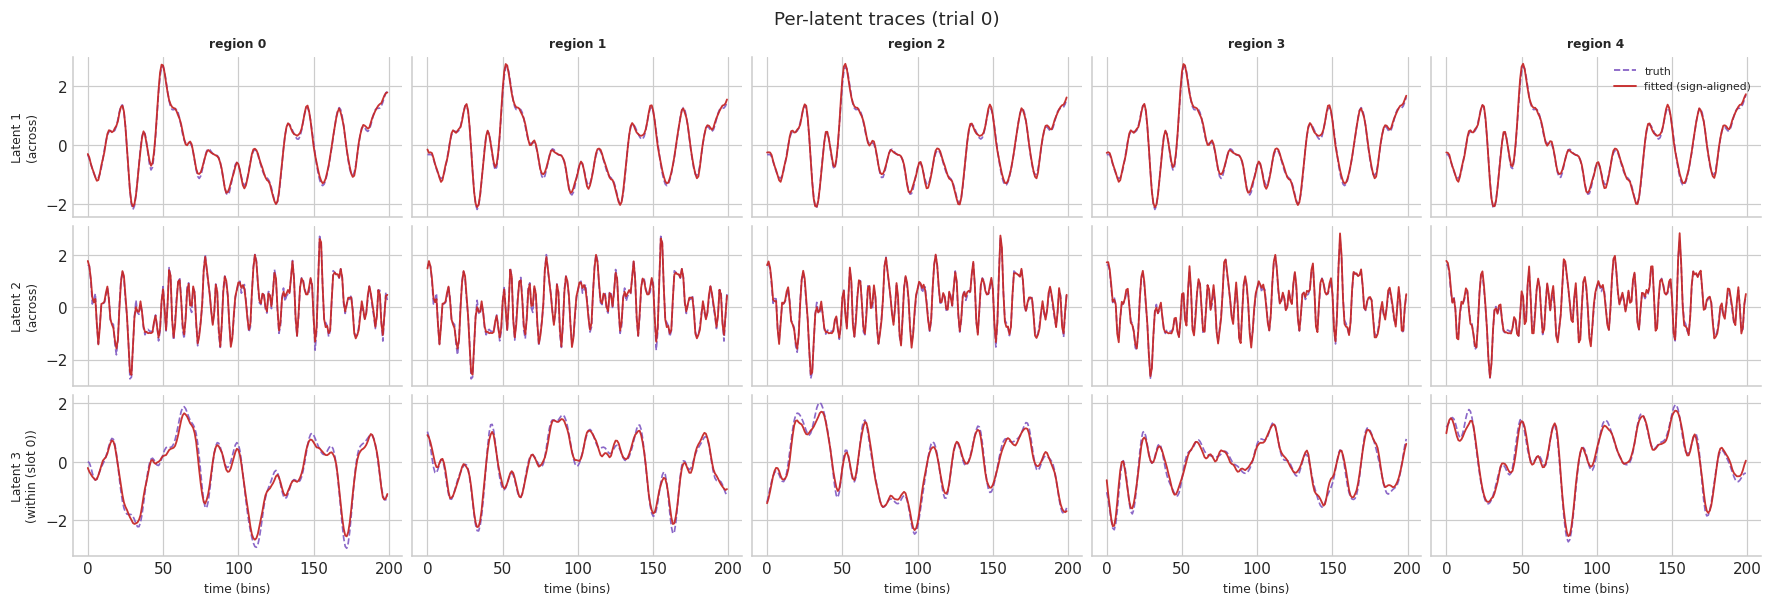

In [7]:
_ = nb.plot_latent_comparison(
    truth["observable"],
    fitted_obs_aligned,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
    trial=0,
)

## Figure 4 - PSTH matrix comparison

Trial-averaged $y$ -> neuron-by-time heatmap. Three panels: truth | fitted | $\text{fitted} - \text{truth}$. Neurons in natural region-grouped order; horizontal lines mark region boundaries; divergent `RdBu_r` colormap centred at 0.

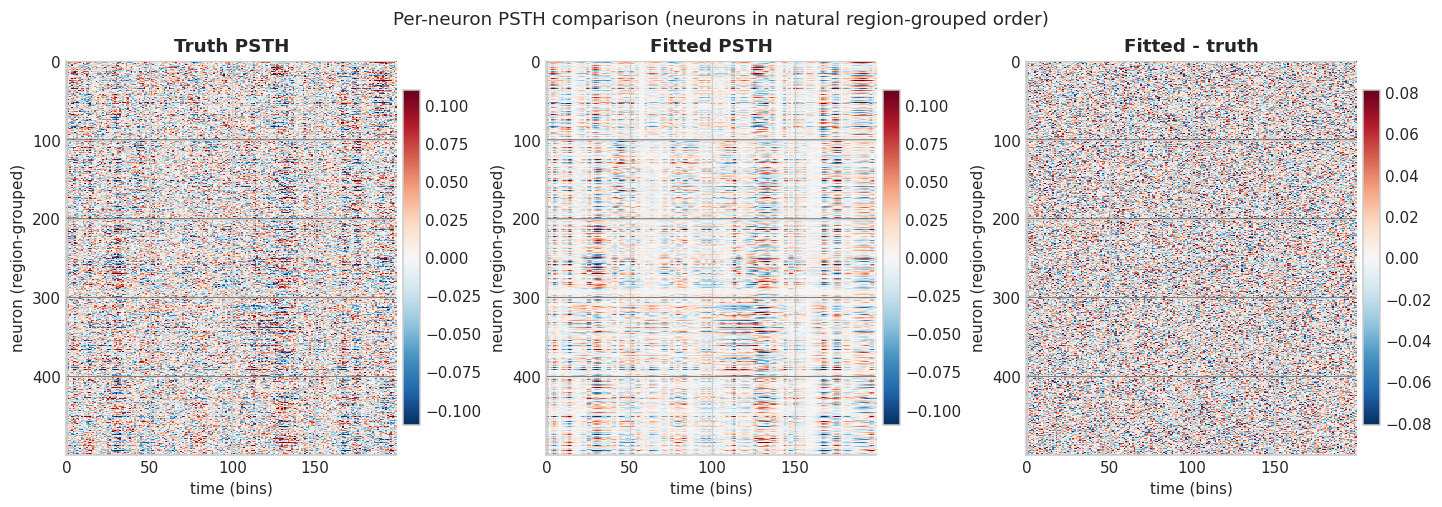

In [8]:
_ = nb.plot_psth_matrix(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
)

## Figure 5 - Trial-0 reconstruction (top-variance neurons per region)

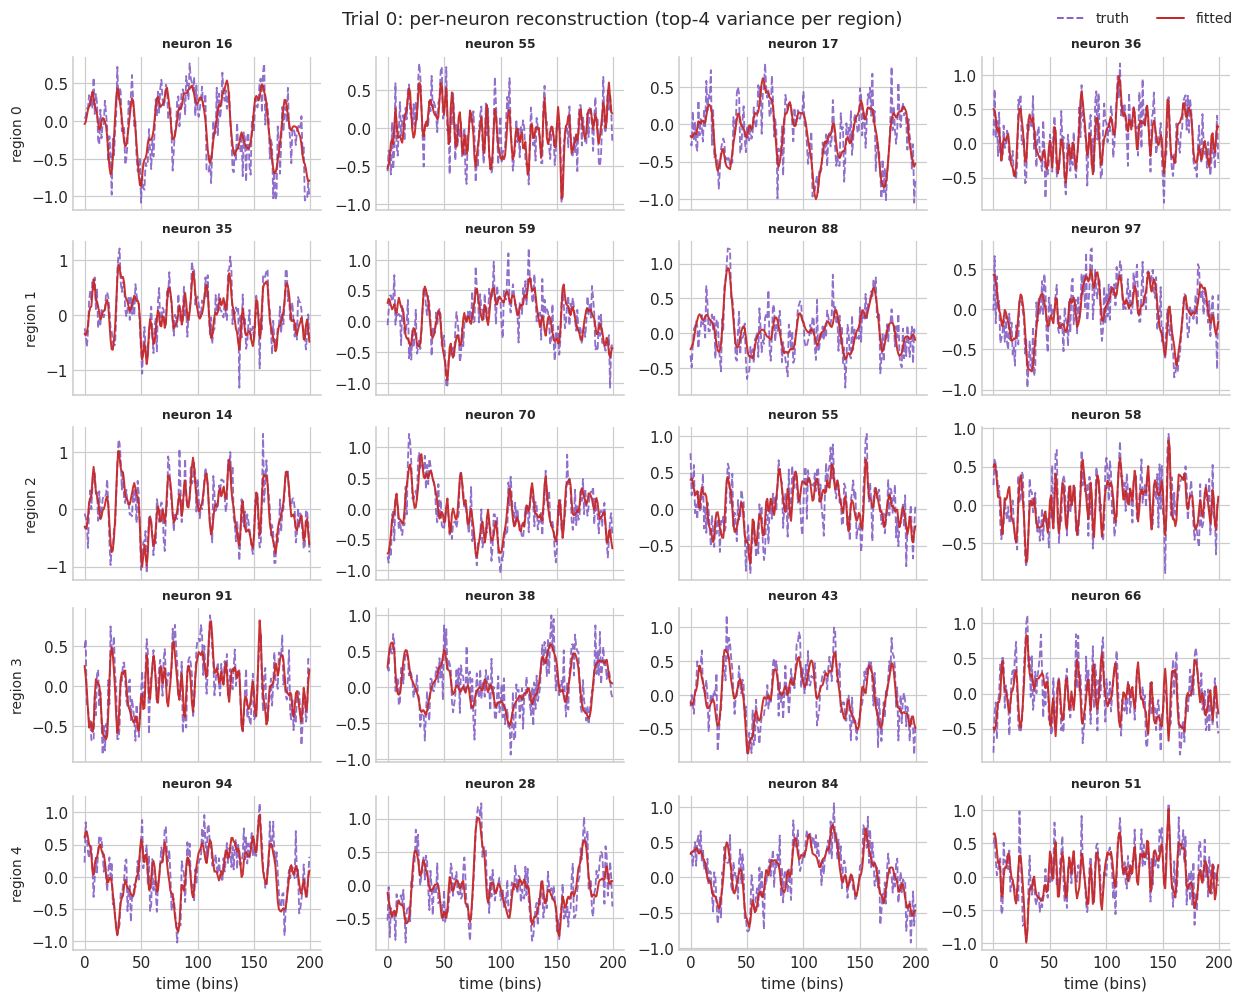

In [9]:
_ = nb.plot_trial0(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
    trial=0,
    n_per_region=4,
)

## Summary

In [10]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"delay_rmse        = {delay_rmse:.4f} bins")
print(f"y_rmse (overall)  = {y_info['overall']:.4f}")
print(f"y_rmse per region = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"across_perm       = {perm}")
print(f"wall time         = {result.wall_time_s:.1f}s")

delay_rmse        = 0.0221 bins
y_rmse (overall)  = 0.2228
y_rmse per region = ['0.2230', '0.2227', '0.2229', '0.2226', '0.2229']
across_perm       = (0, 1)
wall time         = 330.9s
